# TT ChaoticDelayedMatching Troubleshooting

This notebook loads the task-trained `ChaoticDelayedMatching` run through `Analysis_TT` and generates a compact troubleshooting pass over the validation set.

Saved run:

`/home/csverst/Github/CtDBenchmark/content/trained_models/task-trained/tt_ChaoticDelayedMatching`

The first cell includes compatibility shims for older pickle references.

In [1]:
import os
import random
import sys
import types
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.decomposition import PCA


from ctd.task_modeling.task_env.chaotic_delayed_matching import ChaoticDelayedMatching
import ctd.task_modeling.task_env.loss_func as loss_func_mod

from ctd.comparison.analysis.tt.tt import Analysis_TT

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


TT_PATH = "/home/csverst/Github/CtDBenchmark/content/trained_models/task-trained/tt_ChaoticDelayedMatching/"

In [2]:
analysis_tt = Analysis_TT(
    run_name="tt_ChaoticDelayedMatching",
    filepath=TT_PATH,
    use_train_dm=False,
)

wrapper = analysis_tt.wrapper
env = analysis_tt.env
model = analysis_tt.model
datamodule = analysis_tt.datamodule

print(f"Loaded wrapper: {type(wrapper).__name__}")
print(f"Environment: {type(env).__name__}")
print(f"Model: {type(model).__name__}")
print(f"Datamodule: {type(datamodule).__name__}")
print(f"Train trials: {len(datamodule.train_ds)} | Val trials: {len(datamodule.valid_ds)}")
print(f"Timesteps: {env.n_timesteps}")
print(f"Input dim: {env.input_dim} | Output dim: {env.output_dim}")
print(f"Noise: {env.noise}")
print(f"Trim inds: {analysis_tt.trim_inds}")
print(f"Readout neuron index: {getattr(getattr(model, 'readout', None), 'neuron_idx', None)}")

Loaded wrapper: TaskTrainedWrapper
Environment: ChaoticDelayedMatching
Model: ChaoticRateRNN
Datamodule: TaskDataModule
Train trials: 1600 | Val trials: 400
Timesteps: 1050
Input dim: 2 | Output dim: 1
Noise: 0.1
Trim inds: None
Readout neuron index: 44


In [3]:
def add_phase_spans(ax, extra_row):
    ax.axvspan(int(extra_row[0]), int(extra_row[1]), color="tab:blue", alpha=0.12)
    ax.axvspan(int(extra_row[2]), int(extra_row[3]), color="tab:orange", alpha=0.10)
    ax.axvspan(int(extra_row[4]), int(extra_row[5]), color="tab:purple", alpha=0.10)
    ax.axvspan(int(extra_row[6]), int(extra_row[7]), color="tab:red", alpha=0.08)
    ax.axvspan(int(extra_row[8]), int(extra_row[9]), color="tab:green", alpha=0.12)


def compute_trial_metrics(predictions, targets, extra):
    pred = np.asarray(predictions)[..., 0]
    targ = np.asarray(targets)[..., 0]
    extra = np.asarray(extra)

    pred_mean = []
    targ_mean = []
    pred_label = []
    targ_label = []
    mae = []

    for i in range(pred.shape[0]):
        rs = int(extra[i, 8])
        re = int(extra[i, 9])
        pred_window = pred[i, rs:re]
        targ_window = targ[i, rs:re]
        pred_mean_i = float(np.mean(pred_window))
        targ_mean_i = float(np.mean(targ_window))
        pred_mean.append(pred_mean_i)
        targ_mean.append(targ_mean_i)
        pred_label.append(1 if pred_mean_i >= 0 else -1)
        targ_label.append(1 if targ_mean_i >= 0 else -1)
        mae.append(float(np.mean(np.abs(pred_window - targ_window))))

    pred_mean = np.asarray(pred_mean)
    targ_mean = np.asarray(targ_mean)
    pred_label = np.asarray(pred_label)
    targ_label = np.asarray(targ_label)
    mae = np.asarray(mae)

    return {
        "task_accuracy": float(np.mean(pred_label == targ_label)),
        "response_mae_mean": float(np.mean(mae)),
        "response_mae_std": float(np.std(mae)),
        "pred_mean_abs": float(np.mean(np.abs(pred_mean))),
        "pred_mean": pred_mean,
        "targ_mean": targ_mean,
        "pred_label": pred_label,
        "targ_label": targ_label,
        "response_mae": mae,
    }


def summarize_outputs(outputs):
    controlled = outputs["controlled"].detach().cpu().numpy()
    latents = outputs["latents"].detach().cpu().numpy()
    return {
        "controlled_nan_frac": float(np.mean(~np.isfinite(controlled))),
        "latents_nan_frac": float(np.mean(~np.isfinite(latents))),
        "controlled_abs_max": float(np.max(np.abs(controlled))),
        "latents_abs_max": float(np.max(np.abs(latents))),
        "latent_std_mean": float(np.mean(np.std(latents, axis=1))),
    }

In [4]:
ics, inputs, targets = analysis_tt.get_model_inputs("val")
true_inputs = analysis_tt.get_true_inputs("val")
extra = analysis_tt.get_extra_inputs("val").detach().cpu().numpy()
conds = datamodule.valid_ds.tensors[4].detach().cpu().numpy()
outputs = analysis_tt.get_model_outputs("val")

predictions = outputs["controlled"].detach().cpu().numpy()
latents = outputs["latents"].detach().cpu().numpy()
targets_np = targets.detach().cpu().numpy()
inputs_np = inputs.detach().cpu().numpy()
true_inputs_np = true_inputs.detach().cpu().numpy()

metrics = compute_trial_metrics(predictions, targets_np, extra)
output_summary = summarize_outputs(outputs)

print("Troubleshooting metrics")
for key, value in {
    **{k: v for k, v in metrics.items() if isinstance(v, float)},
    **output_summary,
}.items():
    print(f"{key:>20s}: {value:.6f}")

Troubleshooting metrics
       task_accuracy: 1.000000
   response_mae_mean: 0.000091
    response_mae_std: 0.000000
       pred_mean_abs: 0.999909
 controlled_nan_frac: 0.000000
    latents_nan_frac: 0.000000
  controlled_abs_max: 0.999909
     latents_abs_max: 5.000000
     latent_std_mean: 1.162095


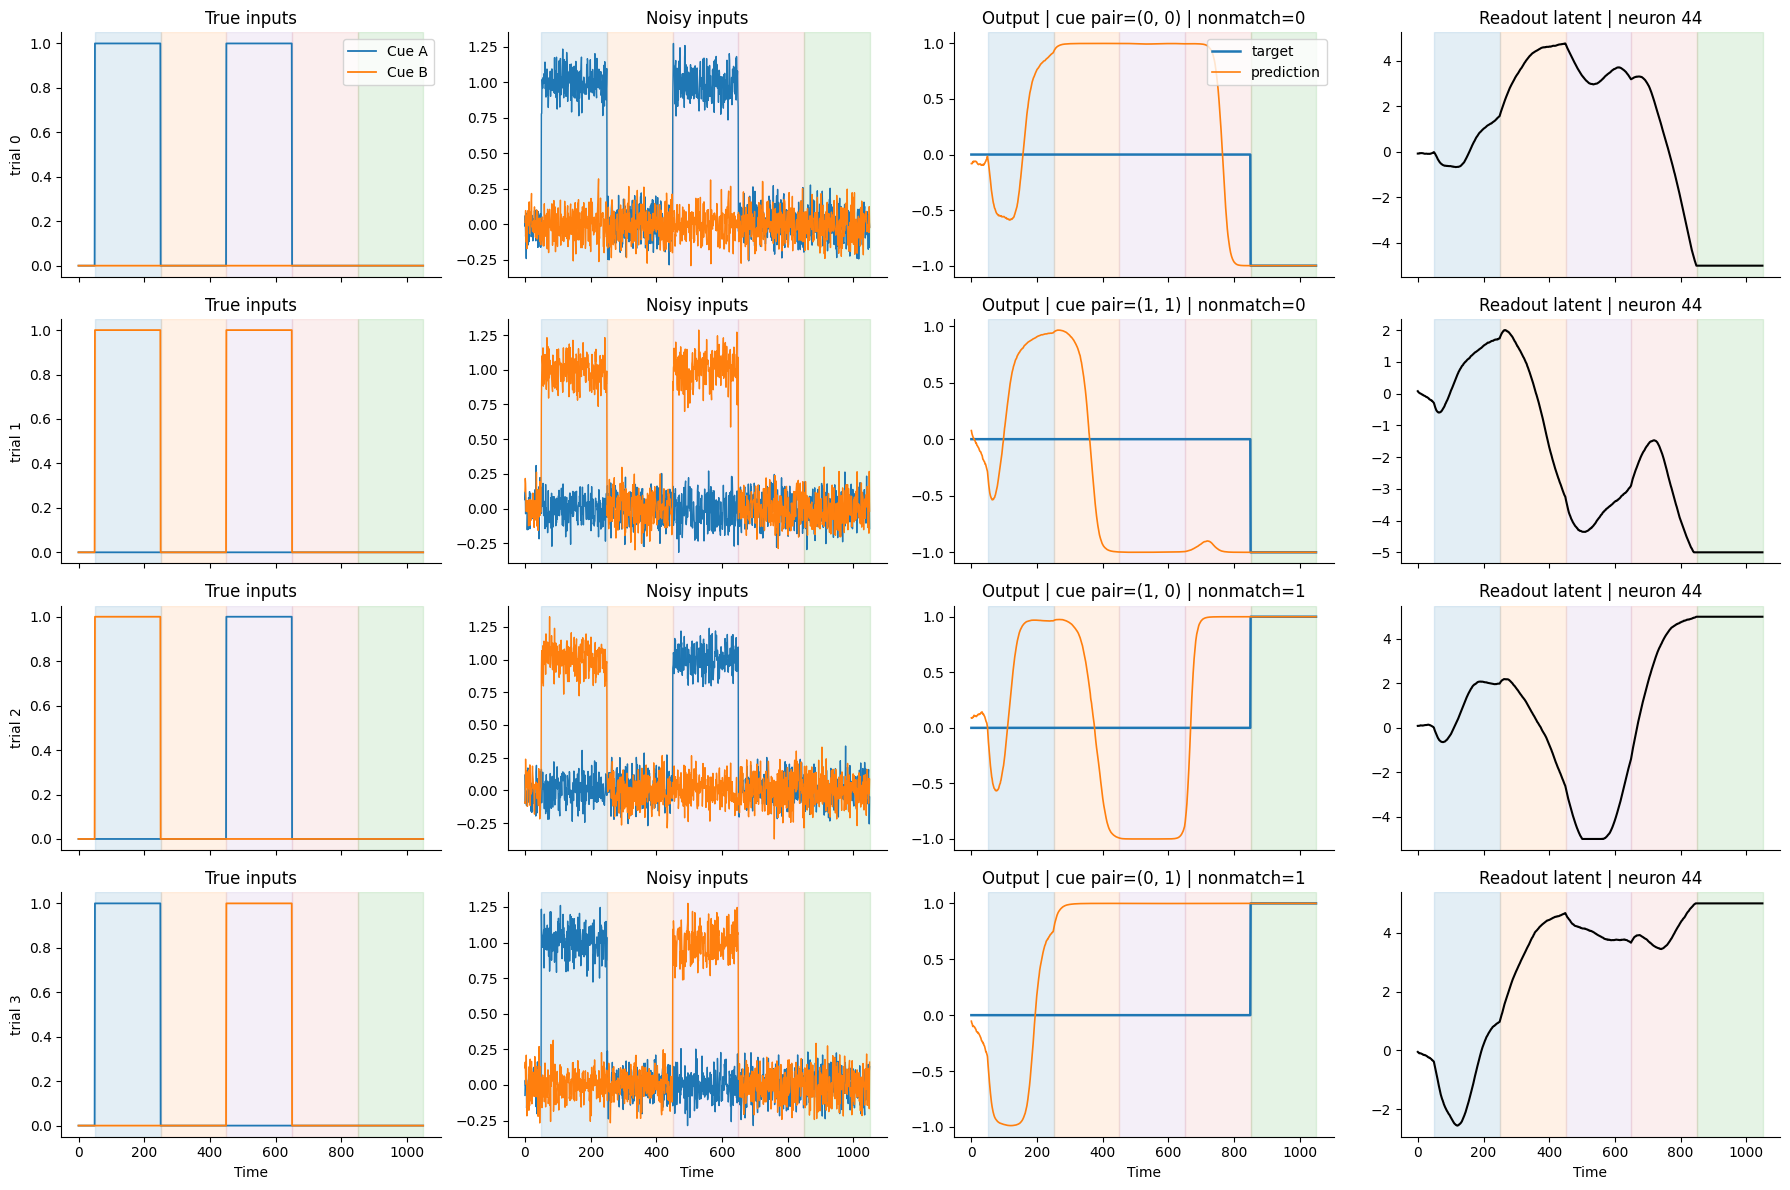

In [5]:
trial_ids = [0, 1, 2, 3]
t = np.arange(env.n_timesteps)

fig, axes = plt.subplots(len(trial_ids), 4, figsize=(18, 3 * len(trial_ids)), sharex=True)
if len(trial_ids) == 1:
    axes = np.array([axes])

for row, trial_idx in enumerate(trial_ids):
    ax_true_in, ax_in, ax_out, ax_lat = axes[row]
    extra_row = extra[trial_idx]

    ax_true_in.plot(t, true_inputs_np[trial_idx, :, 0], label="Cue A", linewidth=1.3)
    ax_true_in.plot(t, true_inputs_np[trial_idx, :, 1], label="Cue B", linewidth=1.3)
    add_phase_spans(ax_true_in, extra_row)
    ax_true_in.set_ylabel(f"trial {trial_idx}")
    ax_true_in.set_title("True inputs")
    if row == 0:
        ax_true_in.legend(loc="upper right")

    ax_in.plot(t, inputs_np[trial_idx, :, 0], linewidth=1.0)
    ax_in.plot(t, inputs_np[trial_idx, :, 1], linewidth=1.0)
    add_phase_spans(ax_in, extra_row)
    ax_in.set_title("Noisy inputs")

    ax_out.plot(t, targets_np[trial_idx, :, 0], label="target", linewidth=1.8)
    ax_out.plot(t, predictions[trial_idx, :, 0], label="prediction", linewidth=1.2)
    add_phase_spans(ax_out, extra_row)
    ax_out.set_title(
        f"Output | cue pair=({int(conds[trial_idx, 0])}, {int(conds[trial_idx, 1])}) "
        f"| nonmatch={int(conds[trial_idx, 2])}"
    )
    if row == 0:
        ax_out.legend(loc="upper right")

    readout_idx = getattr(getattr(model, "readout", None), "neuron_idx", None)
    if readout_idx is not None:
        ax_lat.plot(t, latents[trial_idx, :, readout_idx], color="black", linewidth=1.5)
        ax_lat.set_title(f"Readout latent | neuron {readout_idx}")
    else:
        ax_lat.plot(t, np.linalg.norm(latents[trial_idx], axis=-1), color="black", linewidth=1.5)
        ax_lat.set_title("Latent norm")
    add_phase_spans(ax_lat, extra_row)

for ax in axes[-1]:
    ax.set_xlabel("Time")

fig.tight_layout()

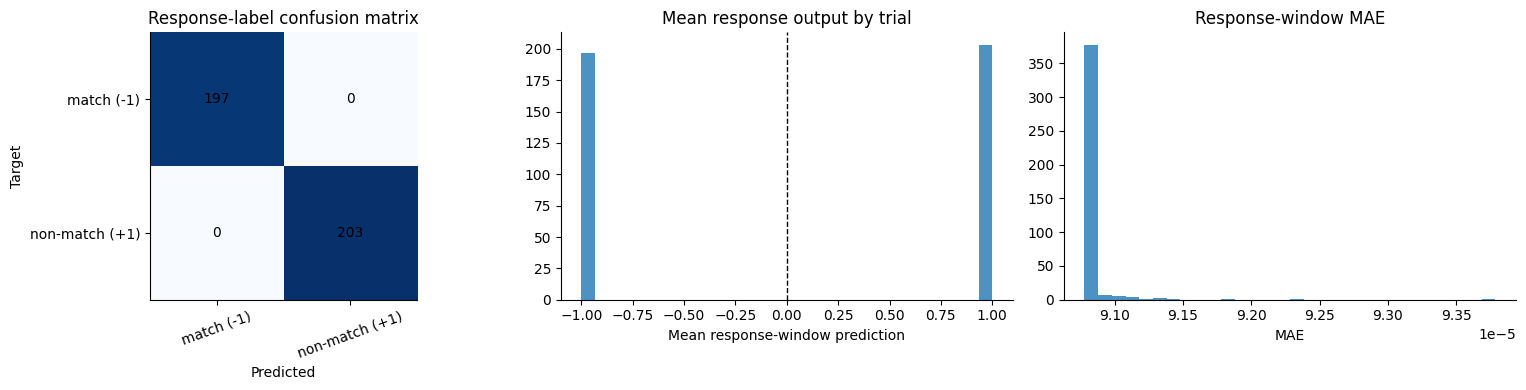

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

label_order = [-1, 1]
cm = np.zeros((2, 2), dtype=int)
for targ_label, pred_label in zip(metrics["targ_label"], metrics["pred_label"]):
    i = label_order.index(int(targ_label))
    j = label_order.index(int(pred_label))
    cm[i, j] += 1

axes[0].imshow(cm, cmap="Blues")
axes[0].set_xticks([0, 1], labels=["match (-1)", "non-match (+1)"], rotation=20)
axes[0].set_yticks([0, 1], labels=["match (-1)", "non-match (+1)"])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Target")
axes[0].set_title("Response-label confusion matrix")
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha="center", va="center", color="black")

axes[1].hist(metrics["pred_mean"], bins=30, alpha=0.8)
axes[1].axvline(0.0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Mean response output by trial")
axes[1].set_xlabel("Mean response-window prediction")

axes[2].hist(metrics["response_mae"], bins=30, alpha=0.8)
axes[2].set_title("Response-window MAE")
axes[2].set_xlabel("MAE")

fig.tight_layout()

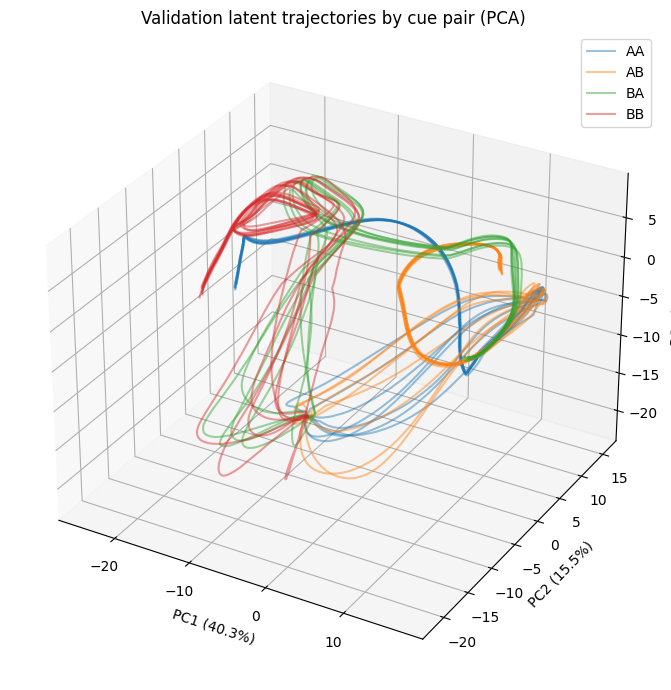

In [7]:
flat_latents = latents.reshape(-1, latents.shape[-1])
pca = PCA(n_components=3)
latents_pca = pca.fit_transform(flat_latents).reshape(latents.shape[0], latents.shape[1], 3)

pair_labels = {
    (0, 0): ("AA", "tab:blue"),
    (0, 1): ("AB", "tab:orange"),
    (1, 0): ("BA", "tab:green"),
    (1, 1): ("BB", "tab:red"),
}

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
for cue_pair, (label, color) in pair_labels.items():
    mask = (conds[:, 0] == cue_pair[0]) & (conds[:, 1] == cue_pair[1])
    trial_inds = np.flatnonzero(mask)[:8]
    for i, trial_idx in enumerate(trial_inds):
        curve = latents_pca[trial_idx]
        ax.plot(curve[:, 0], curve[:, 1], curve[:, 2], color=color, alpha=0.45, label=label if i == 0 else None)

ax.set_title("Validation latent trajectories by cue pair (PCA)")
ax.set_xlabel(f"PC1 ({100 * pca.explained_variance_ratio_[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({100 * pca.explained_variance_ratio_[1]:.1f}%)")
ax.set_zlabel(f"PC3 ({100 * pca.explained_variance_ratio_[2]:.1f}%)")
ax.legend(loc="upper right")
plt.tight_layout()

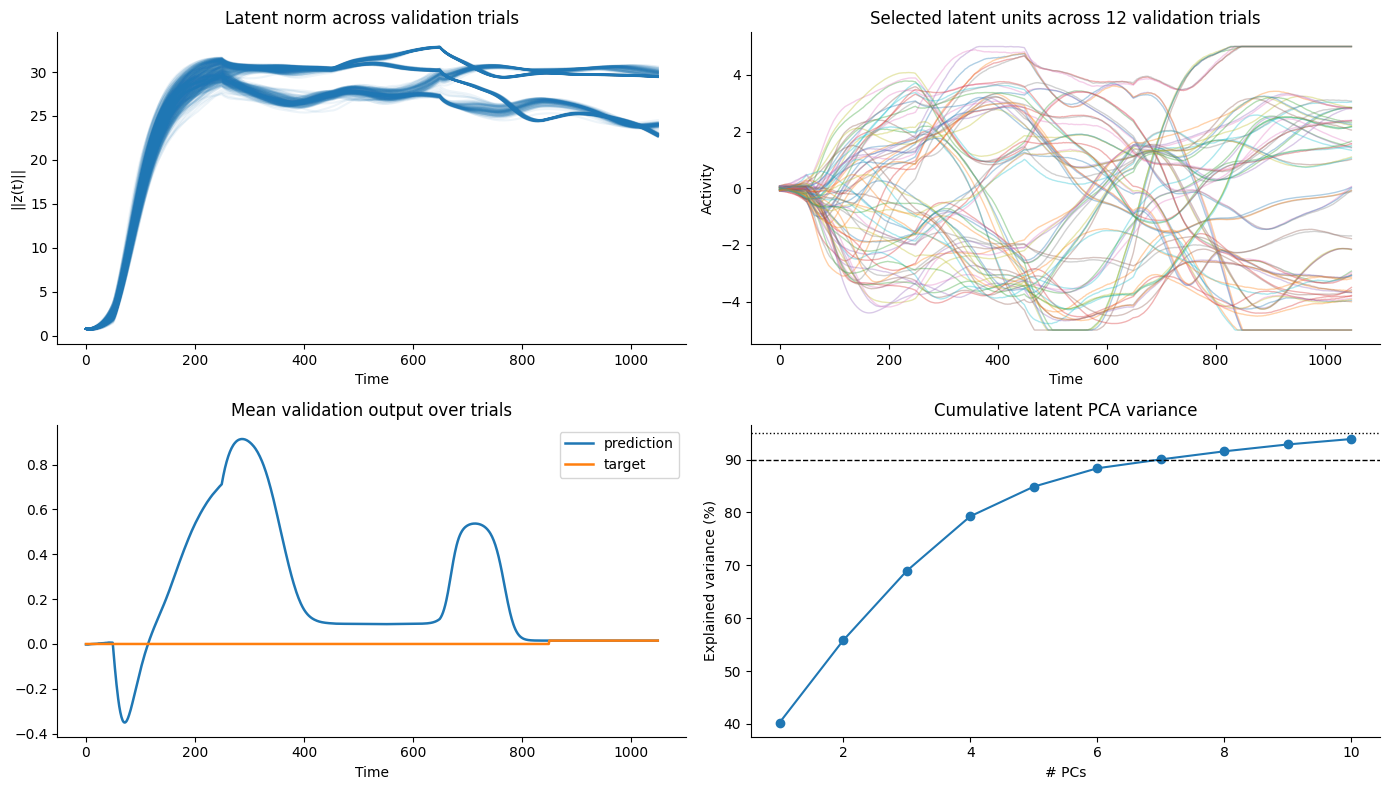

In [8]:
readout_idx = getattr(getattr(model, "readout", None), "neuron_idx", None)
latent_var = np.var(latents, axis=(0, 1))
top_units = np.argsort(latent_var)[-6:][::-1]
if readout_idx is not None and readout_idx not in top_units:
    top_units = np.concatenate([[readout_idx], top_units[:-1]])

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(np.linalg.norm(latents, axis=-1).T, alpha=0.08, color="tab:blue")
axes[0, 0].set_title("Latent norm across validation trials")
axes[0, 0].set_xlabel("Time")
axes[0, 0].set_ylabel("||z(t)||")

for unit_idx in top_units:
    axes[0, 1].plot(latents[:12, :, unit_idx].T, alpha=0.35, linewidth=1)
axes[0, 1].set_title("Selected latent units across 12 validation trials")
axes[0, 1].set_xlabel("Time")
axes[0, 1].set_ylabel("Activity")

axes[1, 0].plot(np.mean(predictions[..., 0], axis=0), linewidth=1.8)
axes[1, 0].plot(np.mean(targets_np[..., 0], axis=0), linewidth=1.8)
axes[1, 0].set_title("Mean validation output over trials")
axes[1, 0].set_xlabel("Time")
axes[1, 0].legend(["prediction", "target"])

pcs = PCA(n_components=min(10, latents.shape[-1]))
pcs.fit(flat_latents)
axes[1, 1].plot(np.arange(1, len(pcs.explained_variance_ratio_) + 1), 100 * np.cumsum(pcs.explained_variance_ratio_), marker="o")
axes[1, 1].axhline(90, color="black", linestyle="--", linewidth=1)
axes[1, 1].axhline(95, color="black", linestyle=":", linewidth=1)
axes[1, 1].set_title("Cumulative latent PCA variance")
axes[1, 1].set_xlabel("# PCs")
axes[1, 1].set_ylabel("Explained variance (%)")

fig.tight_layout()